In [ ]:
#####################
#Loading Packages and Reading Data

In [2]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [ ]:
#1D Entrainment Vertical Profile

In [2]:
# #TESTING TESTING TESTING
# #TESTING #TESTING ***
# data=data.isel(time=slice(0,10),zh=slice(0,5),zf=slice(0,5))
# parcel=parcel.isel(time=slice(0,10),xh=slice(0,10)) #100 parcels, 10 ts

# x_data=parcel['x'].data
# y_data=parcel['y'].data
# z_data=parcel['z'].data

# #TEST DATA SET
# parcel['x'].values[0:10, 0:10] = -250525
# parcel['y'].values[0:10, 0:10] = -44525

# # Modify 'z' variable
# parcel['z'].values[0:5, 0:5] = 200
# parcel['z'].values[0:5, 5:10] = 200
# parcel['z'].values[5:10, 0:5] = 80
# parcel['z'].values[5:10, 5:10] = 300

# data['w'].values[0:5]=0
# data['qc'].values[0:5]=0
# data['w'].values[5:10]=10
# data['qc'].values[5:10]=10

In [5]:
###################################################
# Functions

In [3]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

Text(0, 0.5, 'm(t) (kg/parcel)')

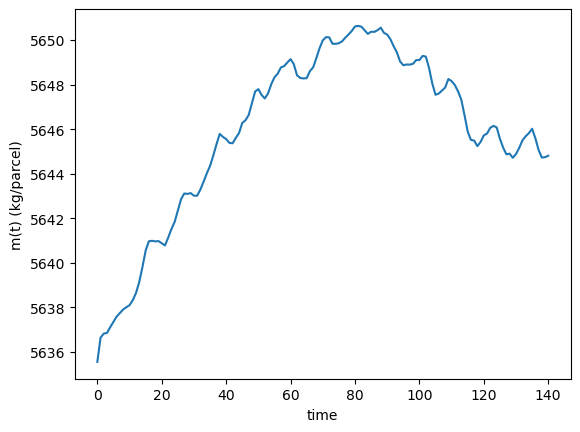

In [65]:
# ts=np.arange(len(data['time']))
# ms=[]
# for ind in ts:
#     ms.append(m(ind))

# plt.plot(ts,ms);plt.xlabel('time');plt.ylabel('m(t) (kg/parcel)')

In [4]:
########################################################
#Calculating Horizontally Averaged Entrainment Rate (KYONGMIN YEO AND DAVID M. ROMPS 2012)
#In the Lagrangian framework, the local entrainment rate e(x, t) is the number of particles that switch from inactive to active in each grid cell over some averaging time. 


if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    # variable='th'; th_data=data[variable].data # get qc data
    # variable='buoyancy'; buoyancy_data=data[variable].data # get qc data

    x_data=parcel['x'].data
    y_data=parcel['y'].data
    z_data=parcel['z'].data
    print('done loading')
    emptylike=True

def A_ind3d(i,t,type):
    #1s or 0s if parcel evaluates threshold for ith parcel at time t

    #(x,y,z) eulerian grid location
    x=x_data[t,i]
    y=y_data[t,i]
    z=z_data[t,i]
    
    xh_val=data['xh'].values*1000; which_x=np.searchsorted(xh_val,x)-1; which_x=np.where(which_x == -1, 0, which_x) #finds which xh layer parcel in
    yh_val=data['yh'].values*1000; which_y=np.searchsorted(yh_val,y)-1; which_y=np.where(which_y == -1, 0, which_y) #finds which yh layer parcel in
    # ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0];which_y=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0].item()
    # xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0];which_x=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0].item()
    zf_val=data['zf'].values*1000; which_z=np.searchsorted(zf_val,z)-1; which_z=np.where(which_z == -1, 0, which_z) #finds which zf layer parcel in 

    #Data
    w=w_data[t,which_z,which_y,which_x]
    qc=qc_data[t,which_z,which_y,which_x]
    qi=qi_data[t,which_z,which_y,which_x]

    #Threshholds
    qcqi_thresh=1e-9 #kg/kg
    w_thresh=0.5 #m/s

    if type=='general':
        A=np.where((w > w_thresh), 1, 0).item() #general updraft
    elif type=='cloudy':
        A=np.where((qc + qi > qcqi_thresh) & (w > w_thresh), 1, 0).item() #cloudy updraft

    # if A==1: print(f'qc+qi: {qc+qi}',f'w: {w}') #TESTING***
    return A 



def which_parcel1d(z,t): #finds which parcels are in the z at time t
    k=z
    Z=z_data[t]
    
    dz=zf(k+1)-zf(k)
    Iz=[zs[k]-dz/2,zs[k]+dz/2]
    
    out=np.where((Z >= Iz[0]) & (Z <= Iz[1]))[0]
    return out


def I_ind1d(z,i,t): #z interval indictator function 
    k=z
    dz=zf(k+1)-zf(k)
    Iz=[zs[k]-dz/2,zs[k]+dz/2]
    Z=z_data[t,i]
    if Iz[0] <= Z <= Iz[1]:
        out=1
    else: 
        out=0
    return out
    
def H_ind_e(x): #Heaviside unit step function
    if x>0:
        out=1
    else:
        out=0 
    return out
    
def H_ind_d(x): #Heaviside unit step function
    if x<0:
        out=-1
    else:
        out=0 
    return out

def H_ind_m(x): #Heaviside unit step function
    if x>0:
        out=1
    elif x<0:
        out=-1 #why not allow for negative entrainement (detrainment)
    elif x==0: 
        out=0
    return out

loading neccessary variables
done loading


In [5]:
# Calculate Entrainment
def ed1d(z,t,type,ed_type): #horizontal averaged entrainment rate
    m_out=m(t)
    dz=zf(z+1)-zf(z)
    # constant=(m_out/Lx/Ly/dz/dt) 
    constant=1 #TESTING***

    #subsets only parcel that are entrainment candidates
    ##################################################################
    one=which_parcel1d(z,t) #checks if parcel is in the box at time t,
    # which_parcel_out=one[0]
    two=which_parcel1d(z,t-1) 
    which_parcel_out=np.intersect1d(one, two)
    ##################################################################

    if ed_type=='e':
        H_ind_ed=H_ind_e
    elif ed_type=='d':
        H_ind_ed=H_ind_d

    out=0 #initialize output
    # for i in range(Np):
    for count,i in enumerate(which_parcel_out):
        if np.mod(count,500)==0: print(f'{count}/{len(which_parcel_out)}')
        A1=A_ind3d(i,t,type);A2=A_ind3d(i,t-1,type); 
        H=H_ind_ed(A1-A2)
        I=I_ind1d(z,i,t)
        out+=constant*H*I

        # print('A1','A2','H','I');print(f'{A1}',f' {A2}',f' {H}',f'{I}');print('-'*40); #TESTING***
        # if count == 100: break
    return out #num/s

ed1d(z=10,t=100,type='cloudy',ed_type='e')

0/2184
500/2184
1000/2184
1500/2184
2000/2184


7

In [198]:
#Entrainment Array

def ed_profile1d(type,ed_type):
    global w_thresh
    #thresholds
    w_thresh=0.1 #1 #m/s
    qcqithresh=1e-6 #kg/kg

    nt=len(data['time'])
        
    #get qc and interpolated w 

    # finds regions that match the threshold
    if type=="general":
        where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
    elif type=='cloudy': 
        where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
    #creates 3d storage array
    tlen=len(data['time'])
    zlen=len(data['zh'])
    profile_array=np.zeros((tlen,zlen))

    #old profile array
    # zhs=data['zh'].values
    # profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    # profile_array[:,2]=zhs

    #get incidies associated with threshold mask
    t_ind, z_ind, y_ind, x_ind = where_updraft

    #remove repeated (t,z) indexes
    tz = np.column_stack((t_ind, z_ind))
    tz_unique=np.unique(tz, axis=0)
    t_ind, z_ind = tz_unique[:, 0], tz_unique[:, 1]


    #bin masked values by z level
    for count,(th,kh) in enumerate(zip(t_ind,z_ind)):
        # if np.mod(count,100)==0: print(f'\n{count*100/len(t_ind):.2f} %\n')
        if np.mod(count,100)==0: print(f'\n{count}/{len(t_ind):.2f}\n')
        value=ed1d(kh,th,type,ed_type)
        profile_array[th,kh]+=value #adds data to scalar array
        # if count == 100: break #TESTING
    return profile_array

In [ ]:
print('running cloudy entrainment profile'); e_profile=ed_profile1d('cloudy','e');
np.save(dir+'tracking_algorithms/ENTRAINMENT_PROFILE_Cloudy_Entrain_1D.npy', e_profile)

print('running cloudy entrainment profile'); d_profile=ed_profile1d('cloudy','d');
np.save(dir+'tracking_algorithms/DETRAINMENT_PROFILE_Cloudy_Entrain_1D.npy', d_profile)

Text(0.5, 0, 't (5 mins)')

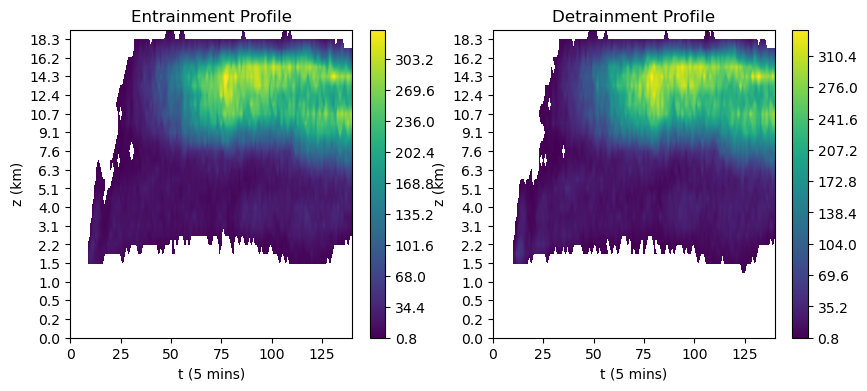

In [106]:
# Load data
# e_profile = np.load(dir + 'tracking_algorithms/ENTRAINMENT_PROFILE_Cloudy_Entrain_1D_w0.1qcqi1e-6.npy')  # cloudy updraft
# d_profile = np.load(dir + 'tracking_algorithms/DETRAINMENT_PROFILE_Cloudy_Entrain_1D_w0.1qcqi1e-6.npy')
e_profile = np.load(dir + 'tracking_algorithms/ENTRAINMENT_PROFILE_Cloudy_Entrain_1D.npy')  # cloudy updraft
d_profile = np.load(dir + 'tracking_algorithms/DETRAINMENT_PROFILE_Cloudy_Entrain_1D.npy')
d_profile*=-1

e_profile[e_profile==0]=np.nan
d_profile[d_profile==0]=np.nan

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 4))
gs = GridSpec(1, 2, figure=fig)
num_levels=500

# First subplot
ax1 = fig.add_subplot(gs[0, 0])
contour1 = ax1.contourf(e_profile.T,levels=num_levels)#,origin='upper')
fig.colorbar(contour1, ax=ax1)
ax1.set_title("Entrainment Profile")

# Second subplot
ax2 = fig.add_subplot(gs[0, 1])
contour2 = ax2.contourf(d_profile.T,levels=num_levels)#,origin='upper')
fig.colorbar(contour2, ax=ax2)
ax2.set_title("Detrainment Profile")


#Fixing Ticks
tick_inds=np.arange(0,len(data['zh'].values),2)
ax1.set_yticks(ticks=tick_inds, labels=np.round(data['zh'].values[tick_inds], 1));
ax2.set_yticks(ticks=tick_inds, labels=np.round(data['zh'].values[tick_inds], 1));

#Axis Labels
ax1.set_ylabel('z (km)')
ax1.set_xlabel('t (5 mins)')
ax2.set_ylabel('z (km)')
ax2.set_xlabel('t (5 mins)')

Text(0.5, 1.0, 'w(z,t)')

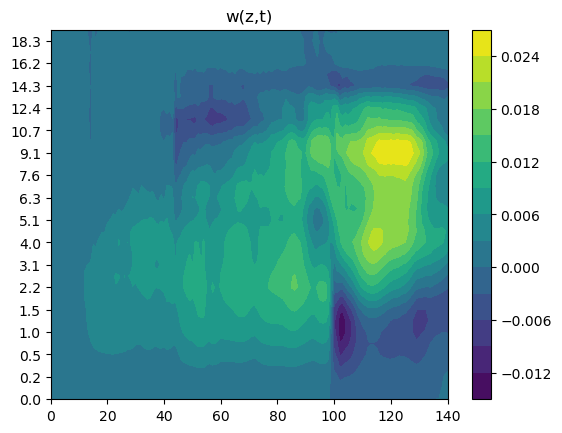

In [9]:
plt.contourf(np.mean(w_data,axis=(2,3)).T,levels=15)
plt.colorbar()


tick_inds=np.arange(0,len(data['zh'].values),2)
plt.yticks(ticks=tick_inds, labels=np.round(data['zh'].values[tick_inds], 1));
plt.title('w(z,t)')

Text(0.5, 1.0, 'qc+qi(z,t)')

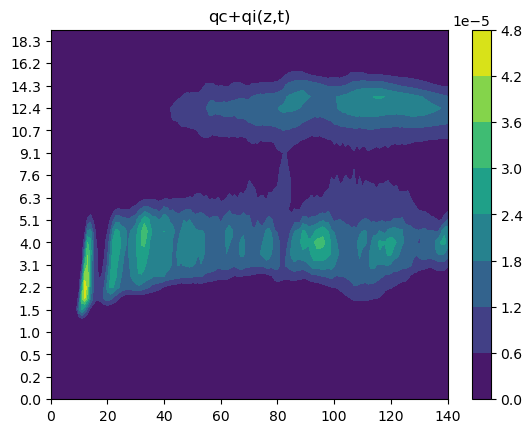

In [10]:
plt.contourf(np.mean(qc_plus_qi,axis=(2,3)).T)
plt.colorbar()


tick_inds=np.arange(0,len(data['zh'].values),2)
plt.yticks(ticks=tick_inds, labels=np.round(data['zh'].values[tick_inds], 1));
plt.title('qc+qi(z,t)')

Text(0.5, 1.0, 'cloudy updraft location (z,t)')

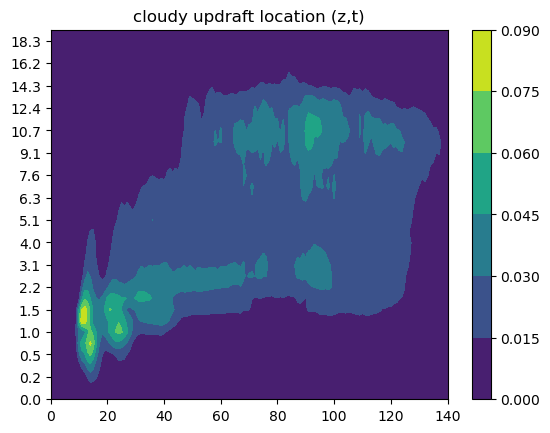

In [29]:
arr=np.zeros_like(w_data)
# arr[np.where((w_data>=1)&(qc_plus_qi>=1e-6))]=1
# arr[np.where((w_data>=1)&(qc_plus_qi>=1e-9))]=1
arr[np.where((w_data>=0.5)&(qc_plus_qi>=1e-9))]=1
# arr[np.where((w_data>=0.1)&(qc_plus_qi>=1e-6))]=1
# arr[np.where((w_data>=0.1)&(qc_plus_qi>=1e-9))]=1

plt.contourf(np.mean(arr,axis=(2,3)).T)
plt.colorbar()


tick_inds=np.arange(0,len(data['zh'].values),2)
plt.yticks(ticks=tick_inds, labels=np.round(data['zh'].values[tick_inds], 1));
plt.title('cloudy updraft location (z,t)')

Text(0.5, 1.0, 'Detrainment Profile')

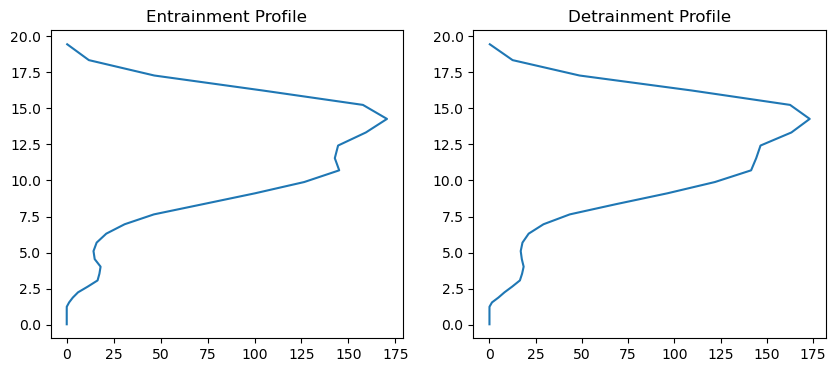

In [61]:
# e_profile = np.load(dir + 'tracking_algorithms/ENTRAINMENT_PROFILE_Cloudy_Entrain_1D_w0.1qcqi1e-6.npy')  # cloudy updraft
# d_profile = np.load(dir + 'tracking_algorithms/DETRAINMENT_PROFILE_Cloudy_Entrain_1D_w0.1qcqi1e-6.npy')
e_profile = np.load(dir + 'tracking_algorithms/ENTRAINMENT_PROFILE_Cloudy_Entrain_1D.npy')  # cloudy updraft
d_profile = np.load(dir + 'tracking_algorithms/DETRAINMENT_PROFILE_Cloudy_Entrain_1D.npy')
d_profile*=-1
e_vert=np.mean(e_profile,axis=0)
d_vert=np.mean(d_profile,axis=0)

fig = plt.figure(figsize=(10, 4))
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(e_vert,data['zh'])
# ax1.plot(e_vert[::-1],data['zh'])
ax1.set_title("Entrainment Profile")

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(d_vert,data['zh'])
# ax2.plot(d_vert[::-1],data['zh'])
ax2.set_title("Detrainment Profile")


In [ ]:
#3D Entrainment Vertical Array
############################################################

In [ ]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [102]:
#Define Indicator Functions
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    # variable='th'; th_data=data[variable].data # get qc data
    # variable='buoyancy'; buoyancy_data=data[variable].data # get qc data

    x_data=parcel['x'].data
    y_data=parcel['y'].data
    z_data=parcel['z'].data
    print('done loading')
    emptylike=True


def A_ind3d(i,t,type):
    #1s or 0s if parcel evaluates threshold for ith parcel at time t

    #(x,y,z) eulerian grid location
    # x=parcel['x'].isel(time=t,xh=i).values
    # y=parcel['y'].isel(time=t,xh=i).values
    # z=parcel['z'].isel(time=t,xh=i).values
    x=x_data[t,i]
    y=y_data[t,i]
    z=z_data[t,i]
    
    xh_val=data['xh'].values*1000; which_xh=np.searchsorted(xh_val,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which xh layer parcel in
    yh_val=data['yh'].values*1000; which_yh=np.searchsorted(yh_val,y)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which yh layer parcel in
    # ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0];which_y=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0].item()
    # xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0];which_x=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0].item()
    zf_val=data['zf'].values*1000; which_z=np.searchsorted(zf_val,z)-1; which_z=np.where(which_z == -1, 0, which_z) #finds which zf layer parcel in 

    #Data
    # qc=data['qc'].isel(time=t,zh=which_z,yh=which_y,xh=which_x).values
    # qi=data['qi'].isel(time=t,zh=which_z,yh=which_y,xh=which_x).values
    # w=data['w'].isel(time=t).interp(zf=data['zh']).isel(zh=which_z,yh=which_y,xh=which_x).values
    qc=qc_data[t,which_z,which_y,which_x]
    qi=qi_data[t,which_z,which_y,which_x]
    w=w_data[t,which_z,which_y,which_x]

    #Threshholds
    qcqi_thresh=1e-9 #kg/kg
    w_thresh=0.5 #1 #m/s

    if type=='general':
        A=np.where((w > w_thresh), 1, 0).item() #general updraft
    elif type=='cloudy':
        A=np.where((qc + qi > qcqi_thresh) & (w > w_thresh), 1, 0).item() #cloudy updraft

    # if A==1: print(f'qc+qi: {qc+qi}',f'w: {w}') #TESTING***
    return A 
    
def I_ind3d(x,y,z,i,t): #z interval indictator function 
    k=z
    dz=zf(k+1)-zf(k)
    Ix=[xs[x]-dx/2,xs[x]+dx/2]
    Iy=[ys[y]-dy/2,ys[y]+dy/2]    
    Iz=[zs[z]-dz/2,zs[z]+dz/2]
    # X=parcel['x'].isel(time=t,xh=i)
    # Y=parcel['y'].isel(time=t,xh=i)
    # Z=parcel['z'].isel(time=t,xh=i)
    X=x_data[t,i]
    Y=y_data[t,i]
    Z=z_data[t,i]

    if (Ix[0] <= X <= Ix[1]) & (Iy[0] <= Y <= Iy[1]) & (Iz[0] <= Z <= Iz[1]):
        out=1
    else: 
        out=0
    return out

def which_parcel3d(x,y,z,t): #finds which parcels are in the gridbox at time t 
    # X=parcel['x'].isel(time=t).values
    # Y=parcel['y'].isel(time=t).values
    # Z=parcel['z'].isel(time=t).values
    X=x_data[t]
    Y=y_data[t]
    Z=z_data[t]

    dz=zf(z+1)-zf(z)
    Ix=[xs[x]-dx/2,xs[x]+dx/2]
    Iy=[ys[y]-dy/2,ys[y]+dy/2]    
    Iz=[zs[z]-dz/2,zs[z]+dz/2]

    # X[:]=Ix[0];Y[:]=Iy[0];Z[:]=Iz[0] #TESTING
    # print(Ix,Iy,Iz) #TESTING

    out=np.where((X >= Ix[0]) & (X <= Ix[1]) &
                 (Y >= Iy[0]) & (Y <= Iy[1]) & 
                 (Z >= Iz[0]) & (Z <= Iz[1]))
    return out

def H_ind_e(x): #Heaviside unit step function
    if x>0:
        out=1
    else:
        out=0 
    return out
    
def H_ind_d(x): #Heaviside unit step function
    if x<0:
        out=-1
    else:
        out=0 
    return out

def H_ind_m(x): #Heaviside unit step function
    if x>0:
        out=1
    elif x<0:
        out=-1 #why not allow for negative entrainement (detrainment)
    elif x==0: 
        out=0
    return out

In [113]:
#Calculating 3-Dimensional Entrainment Rate (KYONGMIN YEO AND DAVID M. ROMPS 2012)
#In the Lagrangian framework, the local entrainment rate e(x, t) is the number of particles that switch from inactive to active in each grid cell over some averaging time
def ed3d(x,y,z,t,type,ed_type): #horizontal averaged entrainment rate
    m_out=m(t)
    dz=zf(z+1)-zf(z)
    # constant=(m_out/dx/dy/dz/dt) 
    constant=1 #TESTING***

    #subsets only parcel that are entrainment candidates
    ##################################################################
    one=which_parcel3d(x,y,z,t) #checks if parcel is in the box at time t
    # which_parcel_out=one[0]
    two=which_parcel3d(x,y,z,t-1) 
    which_parcel_out=np.intersect1d(one, two)
    ##################################################################

    if ed_type=='e':
        H_ind_ed=H_ind_e
    elif ed_type=='d':
        H_ind_ed=H_ind_d
    
    out=0 #initialize output
    # for i in range(Np):
    for count,i in enumerate(which_parcel_out):
        if np.mod(i,5000)==0: print(f'{i}/{Np}')
        A1=A_ind3d(i,t,type);A2=A_ind3d(i,t-1,type); 
        H=H_ind_ed(A1-A2)
        I=I_ind3d(x,y,z,i,t)
        out+=constant*H*I

        # print('A1','A2','H','I');print(A1,A2,H,I);print('-'*40); #TESTING
        # print(f'entrainment: {out}')
    return out #num/s

In [117]:
#Entrainment Array

def ed_profile3d(type,ed_type):
    global w_thresh
    #thresholds
    w_thresh=0.1 #1 #m/s
    qcqithresh=1e-6 #kg/kg

    nt=len(data['time'])
        
    #get qc and interpolated w 

    # finds regions that match the threshold
    if type=="general":
        where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
    elif type=='cloudy': 
        where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
    #creates 3d storage array
    tlen=len(data['time'])
    zlen=len(data['zh'])
    ylen=len(data['yh'])
    xlen=len(data['xh'])
    profile_array=np.zeros((tlen,zlen,ylen,xlen))

    #old profile array
    # zhs=data['zh'].values
    # profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    # profile_array[:,2]=zhs

    #get incidies associated with threshold mask
    t_ind, z_ind, y_ind, x_ind = where_updraft

    #bin masked values by z level
    for count,(th,kh,jh,ih) in enumerate(zip(t_ind,z_ind,y_ind,x_ind)):
        if np.mod(count,100)==0: print(f'{count*100/len(t_ind):.2f} %')
        value=ed3d(ih,jh,kh,th,type,ed_type)
        profile_array[th,kh,jh,ih]+=value #adds data to scalar array
        # if count == 100: break #TESTING***
    return profile_array

In [ ]:
print('running cloudy entrainment profile'); e_profile=ed_profile3d('cloudy','e');
np.save(dir+'tracking_algorithms/ENTRAINMENT_PROFILE_Cloudy_Entrain_3D.npy', e_profile)

print('running cloudy entrainment profile'); d_profile=ed_profile3d('cloudy','d');
np.save(dir+'tracking_algorithms/DETRAINMENT_PROFILE_Cloudy_Entrain_3D.npy', d_profile)

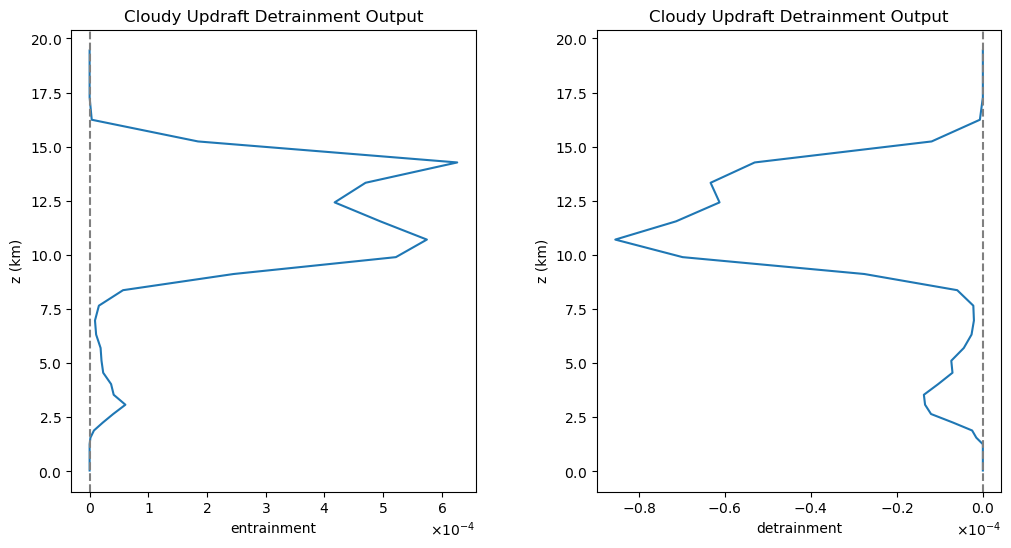

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np

# Directory for loading data
dir = '/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'

# Load data
e_profile = np.load(dir + 'tracking_algorithms/ENTRAINMENT_PROFILE_Cloudy_Entrain_3D.npy')  # cloudy updraft
d_profile = np.load(dir + 'tracking_algorithms/DETRAINMENT_PROFILE_Cloudy_Entrain_3D.npy')

e_profile_vert=np.mean(e_profile,axis=(0,2,3))
d_profile_vert=np.mean(d_profile,axis=(0,2,3))

# Create the gridspec layout
fig = plt.figure(figsize=(12, 6))  # Define the overall figure size
gs = fig.add_gridspec(1, 2, wspace=0.3)  # Create 1 row, 2 columns, adjust spacing

# Plot 1: Updraft Entrainment
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(e_profile_vert,data['zh'])
ax1.axvline(0, linestyle='dashed', color='gray')
ax1.set_ylabel('z (km)')
ax1.set_xlabel('entrainment')
ax1.set_title('Cloudy Updraft Detrainment Output')
# ax1.set_xlim(right=4.5e-4)

# Apply scientific notation formatting
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

# Plot 2: Cloudy Updraft Entrainment
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(d_profile_vert,data['zh'])
ax2.axvline(0, linestyle='dashed', color='gray')
ax2.set_ylabel('z (km)')
ax2.set_xlabel('detrainment')
ax2.set_title('Cloudy Updraft Detrainment Output')
# ax2.set_xlim(right=4.5e-4)

# Apply scientific notation formatting
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

# Show the plot
plt.show()


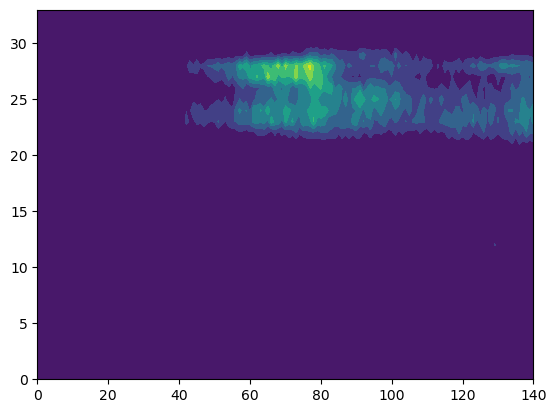

In [31]:
e_profile_vert=np.mean(e_profile,axis=(2,3))
d_profile_vert=np.mean(d_profile,axis=(2,3))
plt.contourf(e_profile_vert.T)